In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

import matplotlib.pyplot as plt
import japanize_matplotlib
plt.style.use("ggplot")

## OLS, BLP操作変数, GH操作変数を用いた線形回帰モデル

In [46]:
data = pd.read_csv("output/processed_data.csv")

# OLSの推定
X = data[["price", "hppw", "FuelEfficiency", "size"]]
X = sm.add_constant(X)
y = data["logit_share"]
model = sm.OLS(y, X).fit(cov_type="HC1")

# BLP操作変数を用いたIV推定
formula = """
logit_share ~ 1 + hppw + FuelEfficiency + size
+ [price ~ iv_BLP_own_hppw
        + iv_BLP_own_FuelEfficiency
        + iv_BLP_own_size
        + iv_BLP_other_hppw
        + iv_BLP_other_FuelEfficiency
        + iv_BLP_other_size]
"""

iv_BLP = IV2SLS.from_formula(
    formula,
    data=data
).fit(cov_type="robust")


# 差別化操作変数を用いたIV推定
formula = """
logit_share ~ 1 + hppw + FuelEfficiency + size
+ [price ~ iv_GH_own_hppw
        + iv_GH_own_FuelEfficiency
        + iv_GH_own_size
        + iv_GH_other_hppw
        + iv_GH_other_FuelEfficiency
        + iv_GH_other_size]
"""

# iv_GH = IV2SLS.from_formula(
#     formula,
#     data=data
# ).fit(cov_type="heteroskedastic")
iv_GH = IV2SLS.from_formula(
    formula,
    data=data
).fit()

In [28]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            logit_share   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     148.5
Date:                Tue, 11 Aug 2026   Prob (F-statistic):          5.39e-110
Time:                        14:33:35   Log-Likelihood:                -3401.3
No. Observations:                1823   AIC:                             6813.
Df Residuals:                    1818   BIC:                             6840.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -12.2548      0.365    -33.591      0.000     -12.970     -11.540
price             -0.2551      0.026     -9.885      0.000      -0.306      -0.205
hppw              -0.6542      1.284     -0.509      0.610      -3.171       1.863
FuelEfficiency     0.1301      0.010     13.358      0.000       0.111       0.149
size               0.1822      0.019      9.633      0.000       0.145       0.219
==============================================================================
Omnibus:                      322.488   Durbin-Watson:                   0.724
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              609.516
Skew:                          -1.073   Prob(JB):                    4.42e-133
Kurtosis:                       4.848   Cond. No.                         858.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [29]:
iv_BLP.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:            logit_share   R-squared:                      0.2216
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2199
No. Observations:                1823   F-statistic:                    482.81
Date:                Tue, Aug 11 2026   P-value (F-stat)                0.0000
Time:                        14:13:48   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                                
==================================================================================
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept         -12.323     0.3815    -32.304     0.0000     -13.071     -11.576
hppw               0.2129     2.2943     0.0928     0.9261     -4.2839      4.7098
FuelEfficiency     0.1298     0.0097     13.328     0.0000      0.1107      0.1489
size               0.1874     0.0211     8.8598     0.0000      0.1459      0.2288
price             -0.2835     0.0669    -4.2352     0.0000     -0.4147     -0.1523
==================================================================================

Endogenous: price
Instruments: iv_BLP_own_hppw, iv_BLP_own_FuelEfficiency, iv_BLP_own_size, iv_BLP_other_hppw, iv_BLP_other_FuelEfficiency, iv_BLP_other_size
Robust Covariance (Heteroskedastic)
Debiased: False
"""

In [47]:
iv_GH.summary

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:            logit_share   R-squared:                      0.1805
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1787
No. Observations:                1823   F-statistic:                    459.59
Date:                Tue, Aug 11 2026   P-value (F-stat)                0.0000
Time:                        15:02:37   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                                
==================================================================================
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept         -12.973     0.3921    -33.084     0.0000     -13.741     -12.204
hppw               8.4256     2.6339     3.1989     0.0014      3.2632      13.588
FuelEfficiency     0.1268     0.0096     13.159     0.0000      0.1079      0.1457
size               0.2363     0.0222     10.660     0.0000      0.1929      0.2798
price             -0.5521     0.0804    -6.8708     0.0000     -0.7096     -0.3946
==================================================================================

Endogenous: price
Instruments: iv_GH_own_hppw, iv_GH_own_FuelEfficiency, iv_GH_own_size, iv_GH_other_hppw, iv_GH_other_FuelEfficiency, iv_GH_other_size
Robust Covariance (Heteroskedastic)
Debiased: False
"""

## 表3.3の再現

In [33]:
# 自己価格弾力性
df_elas = pd.DataFrame()
df_elas["own_price_elasticity_ols"] = model.params["price"] * data["price"] * (1 - data["share"])
df_elas["own_price_elasticity_blp"] = iv_BLP.params["price"] * data["price"] * (1 - data["share"])
df_elas["own_price_elasticity_gh"] = iv_GH.params["price"] * data["price"] * (1 - data["share"])

# 集計した後, 表3.3の形に整形する
table_3_3 = df_elas.describe().T[["mean", "std", "50%","min", "max"]].round(2)
table_3_3.columns = ["平均", "標準偏差", "中央値", "最小値", "最大値"]
table_3_3.index = ["OLS", "BLP操作変数", "差別化操作変数"]
table_3_3

,平均,標準偏差,中央値,最小値,最大値
OLS,-0.65,0.47,-0.52,-3.22,-0.18
BLP操作変数,-0.72,0.52,-0.58,-3.58,-0.20
差別化操作変数,-1.40,1.01,-1.13,-6.97,-0.39


## 支払意思額の推定

In [19]:
list_wtp = []
for m in [model, iv_BLP, iv_GH]:
    list_wtp.append(
        [
            abs(m.params["hppw"]/ m.params["price"]),
            abs(m.params["size"]/ m.params["price"]),
            abs(m.params["FuelEfficiency"]/ m.params["price"])
        ]
    )

print("各変数の支払意思額の推定値")
pd.DataFrame(
    list_wtp, 
    columns=["hppw", "size", "FuelEfficiency"],
    index=["model", "iv_BLP", "iv_GH"]
)*100

各変数の支払意思額の推定値


,hppw,size,FuelEfficiency
model,256.452400,71.428037,51.008701
iv_BLP,75.110093,66.103214,45.793560
iv_GH,1526.022198,42.801875,22.972189


## 図3.1の再現

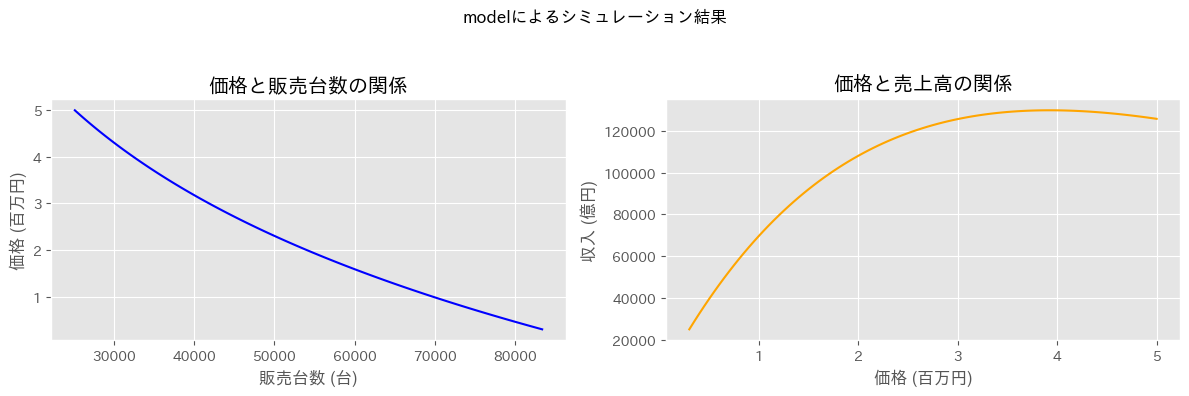

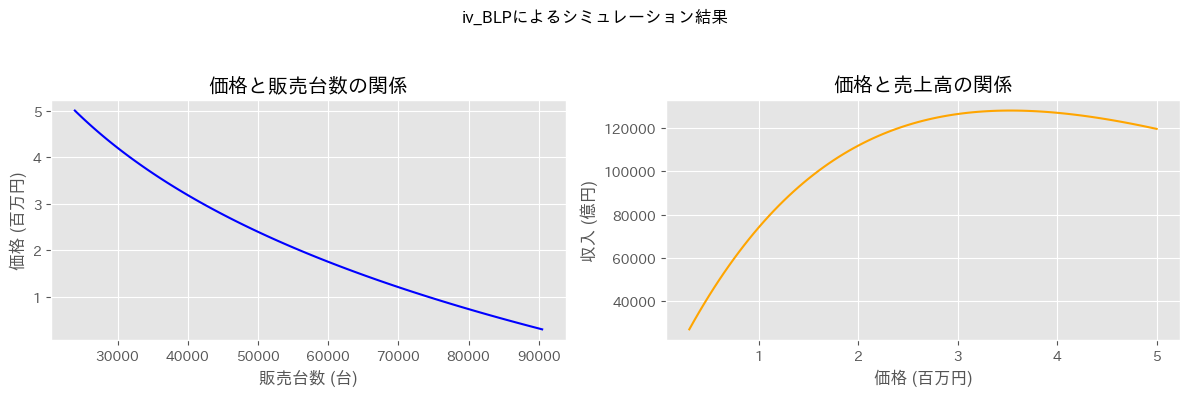

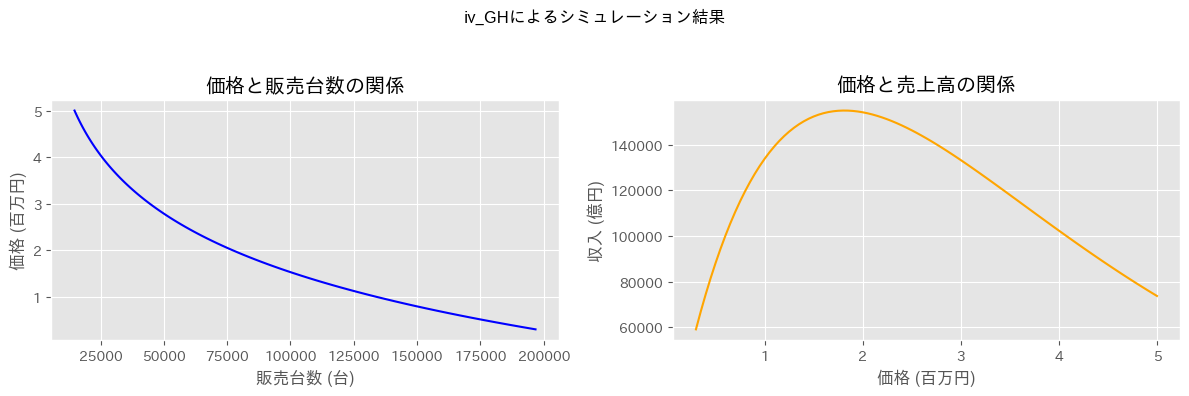

In [ ]:
# 特定の年の製品に限定
d = data[(data["year"]==2016) & (data["NameID"]==87)].copy()

dict_model = {
    "model":model,
    "iv_BLP":iv_BLP,
    "iv_GH":iv_GH
}

def calculate_revenue(price, model_obj, d, xi_fit, target_id=87):

    # 平均効用
    delta = (
        model_obj.params["hppw"] * d["hppw"]
        + model_obj.params["FuelEfficiency"] * d["FuelEfficiency"]
        + model_obj.params["size"] * d["size"]
        + model_obj.params["price"] * price
        + xi_fit
    )

    if "const" in model_obj.params.index:
        delta += model_obj.params["const"]
    elif "Intercept" in model_obj.params.index:
        delta += model_obj.params["Intercept"]

    denom = 1 + sum(np.exp(delta))
    pred_sales = (np.exp(delta) / denom) * d["HH"]

    pred_sale_for_ID = pred_sales[d["NameID"] == target_id].values[0]

    revenue = price * pred_sale_for_ID

    return pred_sale_for_ID, revenue


for modelname, model_obj in dict_model.items():

    pricevec = np.arange(0.3, 5.0 + 0.05, 0.05)
    salesvec = []
    revenuevec = []

    # 残差を計算
    # sm.OLSのみ残差を出力するattributeがresidであるので場合分け
    d[f"{modelname}_resids"] = model_obj.resid if modelname == "model" else model_obj.resids
    xi_fit = d[f"{modelname}_resids"].values[0]

    for price in pricevec:

        pred_sale_for_ID, revenue = calculate_revenue(price, model_obj, d, xi_fit, target_id=87)
        salesvec.append(pred_sale_for_ID)
        revenuevec.append(revenue)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(salesvec, pricevec, color="blue", label="販売台数")
    plt.xlabel("販売台数 (台)")
    plt.ylabel("価格 (百万円)")
    plt.title("価格と販売台数の関係")

    plt.subplot(1, 2, 2)
    plt.plot(pricevec, revenuevec, color="orange", label="売上高")
    plt.xlabel("価格 (百万円)")
    plt.ylabel("収入 (億円)")
    plt.title("価格と売上高の関係")
    plt.suptitle(f"{modelname}によるシミュレーション結果")
    # plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    plt.show()

In [118]:
result = minimize_scalar(
    lambda price: -calculate_revenue(
        price,
        model_obj=model_obj,
        d=d,
        xi_fit=xi_fit
    )[1],
    bounds=(0.3, 3.0),
    method="bounded"
)

optimal_price = result.x

optimal_sales, max_revenue = calculate_revenue(
    optimal_price,
    model_obj=model_obj,
    d=d,
    xi_fit=xi_fit
)

print("最適価格:", optimal_price)
print("販売台数:", optimal_sales)
print("最大売上高:", max_revenue)

最適価格: 1.8138973693418452
販売台数: 85455.79489860105
最大売上高: 155008.0415615887


In [119]:
result

 message: Solution found.
 success: True
  status: 0
     fun: -155008.0415615887
       x: 1.8138973693418452
     nit: 10
    nfev: 10